# ANÁLISIS DE MODELOS — VIDEO FINGER TAPPING MDS-UPDRS 3.4
## Pipeline: Carga → Comparación modelos → Matrices → ROC → Sobreajuste → Estabilidad de features

**Descripción del pipeline:**
- 7 modelos evaluados: LR, KNN, DT, RF, AdaBoost, XGBoost, LDA
- 3 tipos de features: classical, tsfresh y fi_tsfresh
- Validación: LOO nested CV con GridSearchCV interno
- Métrica de optimización: MCC (Matthews Correlation Coefficient)

---
## CELDA 1 — Imports y configuración

In [1]:
"""
============================================================================
IMPORTS Y CONFIGURACIÓN GLOBAL
Centraliza rutas, paletas y parámetros del análisis de modelos.
============================================================================
"""

import os
import pickle
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, roc_auc_score, roc_curve
)
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve, LeaveOneOut

from tsfresh import select_features

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ─────────────────────────────────────────────
# CONFIGURACIÓN — ajustar parámetros aquí
# ─────────────────────────────────────────────
class Config:
    DATASET_ID = "fis"
    FEATURES_TYPES = ["classical", "tsfresh", "fi_tsfresh"]
    RUTA_RESULTS = "../results_files/"
    RUTA_OUTPUT = "../output_files/"
    RUTA_INPUT = "../input_files/"
    RUTA_SALIDA = "../results_files/analisis_modelos/"

    SCORE_COLORS = {0:'#2196F3', 1:'#4CAF50', 2:'#FF9800', 3:'#F44336', 4:'#9C27B0'}
    MODEL_COLORS = {
        'LogisticRegression': '#1976D2',
        'KNeighborsClassifier': '#388E3C',
        'DecisionTreeClassifier': '#F57C00',
        'RandomForestClassifier': '#7B1FA2',
        'AdaBoostClassifier': '#C62828',
        'XGBClassifier': '#00838F',
        'LDA': '#4E342E',
        'LinearDiscriminantAnalysis': '#4E342E'
    }
    METRICAS = ['Accuracy', 'MCC', 'ROC_AUC', 'F1_score', 'Acceptable_accuracy', 'Kappa_score']
    RANDOM_STATE = 12883823

    SUMMARY_PATHS = {
        'classical': f"{RUTA_RESULTS}{DATASET_ID}_classical_execution_summary.csv",
        'tsfresh': f"{RUTA_RESULTS}{DATASET_ID}_tsfresh_execution_summary.csv",
        'fi_tsfresh': f"{RUTA_RESULTS}{DATASET_ID}_fi_tsfresh_execution_summary.csv"
    }
    RAW_PATHS = {
        'classical': f"{RUTA_RESULTS}pickle/{DATASET_ID}_classical_raw_data.pkl",
        'tsfresh': f"{RUTA_RESULTS}pickle/{DATASET_ID}_tsfresh_raw_data.pkl",
        'fi_tsfresh': f"{RUTA_RESULTS}pickle/{DATASET_ID}_fi_tsfresh_raw_data.pkl"
    }
    FEATURES_PATHS = {
        'classical': f"{RUTA_OUTPUT}{DATASET_ID}_classical_features.csv",
        'tsfresh': f"{RUTA_OUTPUT}{DATASET_ID}_tsfresh_features.csv",
        'fi_tsfresh': f"{RUTA_OUTPUT}{DATASET_ID}_fi_tsfresh_features.csv"
    }
    FEATURES_PATH = FEATURES_PATHS['classical']
    DIAG_PATH = f"{RUTA_INPUT}{DATASET_ID}_diagnostic.csv"

os.makedirs(Config.RUTA_SALIDA, exist_ok=True)
os.makedirs(f"{Config.RUTA_SALIDA}/figuras", exist_ok=True)
os.makedirs(f"{Config.RUTA_SALIDA}/tablas", exist_ok=True)

print("✅ Configuración cargada")
print(f"   Dataset ID : {Config.DATASET_ID}")
print(f"   Ruta salida: {Config.RUTA_SALIDA}")

✅ Configuración cargada
   Dataset ID : fis
   Ruta salida: ../results_files/analisis_modelos/


---
## CELDA 2 — Carga de summaries

In [2]:
"""
============================================================================
CARGA DE RESULTADOS DE CLASIFICACIÓN
Lee los summaries y construye una tabla comparativa base.
============================================================================
"""

def _normalizar_columnas(df):
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]
    rename_map = {
        'Acceptable_Accuracy': 'Acceptable_accuracy',
        'Acceptable Accuracy': 'Acceptable_accuracy',
        'Kappa Score': 'Kappa_score',
        'F1 Score': 'F1_score',
        'ROC AUC': 'ROC_AUC'
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
    if 'Model' in df.columns:
        df['Model'] = df['Model'].astype(str).str.strip()
    for col in Config.METRICAS:
        if col not in df.columns:
            df[col] = np.nan
    return df

def cargar_summary(path, features_type):
    if not path or not os.path.exists(path):
        print(f"⚠️ Summary no encontrado: {path}")
        return pd.DataFrame()
    df = pd.read_csv(path, sep=';')
    df = _normalizar_columnas(df)
    df['features_type'] = features_type
    return df

dfs = {}
for ft in Config.FEATURES_TYPES:
    path = Config.SUMMARY_PATHS.get(ft)
    dfs[ft] = cargar_summary(path, ft)

df_classical = dfs.get('classical', pd.DataFrame())
df_tsfresh = dfs.get('tsfresh', pd.DataFrame())
df_fi_tsfresh = dfs.get('fi_tsfresh', pd.DataFrame())

df_all = pd.concat([d for d in dfs.values() if not d.empty], ignore_index=True)

if df_all.empty:
    raise RuntimeError('⚠️ No se encontraron summaries de clasificación.')

metrics_show = ['Accuracy', 'MCC', 'ROC_AUC']
pivot = df_all.pivot_table(index='Model', columns='features_type', values=metrics_show)
print(pivot.to_string())

for ft in Config.FEATURES_TYPES:
    sub = df_all[df_all['features_type'] == ft]
    if sub.empty:
        print(f"⚠️ Sin datos para {ft}")
        continue
    for metric in metrics_show:
        if sub[metric].notna().any():
            best_idx = sub[metric].idxmax()
            best_row = sub.loc[best_idx]
            print(f"★ Mejor {metric} ({ft}): {best_row['Model']} = {best_row[metric]:.3f}")

                        Accuracy                            MCC                        ROC_AUC                     
features_type          classical fi_tsfresh   tsfresh classical fi_tsfresh   tsfresh classical fi_tsfresh   tsfresh
Model                                                                                                              
AdaBoostClassifier      0.613636   0.527273  0.572727  0.416742   0.297247  0.358849  0.754648   0.704171  0.725520
DecisionTreeClassifier  0.577273   0.427273  0.522727  0.381594   0.176197  0.296106  0.690276   0.564037  0.645183
KNeighborsClassifier    0.654545   0.527273  0.609091  0.473245   0.278215  0.399993  0.784304   0.714856  0.757655
LDA                     0.595455   0.527273  0.586364  0.389199   0.283580  0.381294  0.773032   0.737841  0.796346
LogisticRegression      0.604545   0.518182  0.613636  0.399814   0.269218  0.417344  0.769379   0.730896  0.818375
RandomForestClassifier  0.695455   0.509091  0.650000  0.541483   0.2762

---
## CELDA 3 — Tabla resumen comparativa

💾 Tabla comparativa guardada: ../results_files/analisis_modelos//tablas/comparacion_modelos.csv


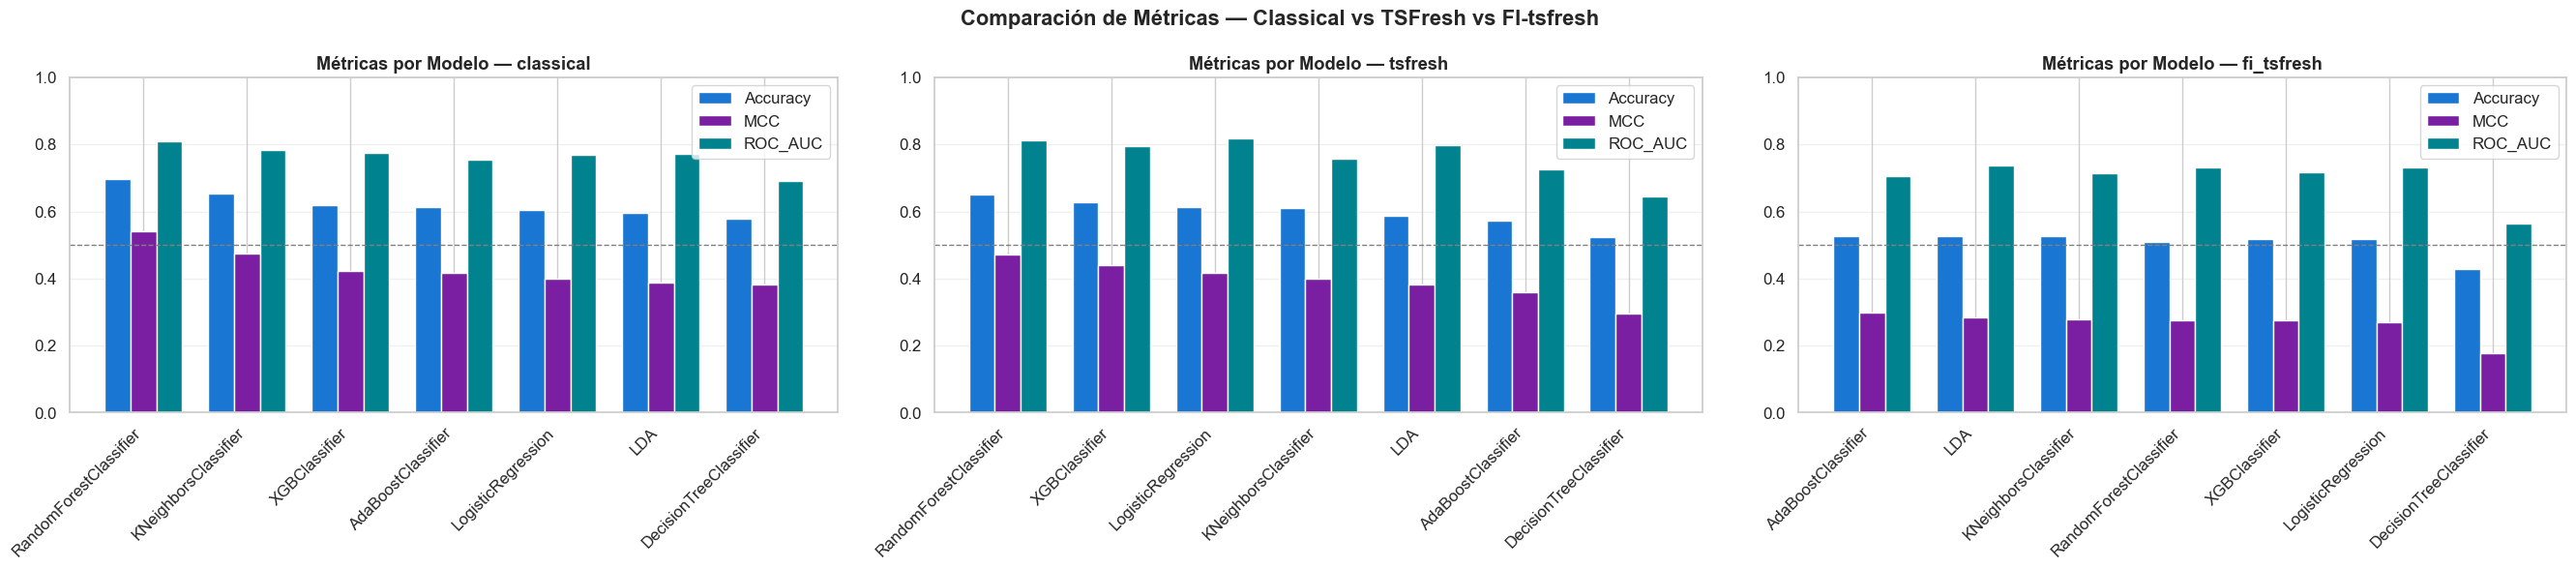

In [3]:
"""
============================================================================
TABLA COMPARATIVA — 7 modelos × 2 tipos de features
Resumen global y comparación visual por métricas clave.
============================================================================
"""

df_comp = df_all.copy()
df_comp = df_comp.sort_values(['features_type', 'MCC'], ascending=[True, False])
csv_comp = f"{Config.RUTA_SALIDA}/tablas/comparacion_modelos.csv"
df_comp.to_csv(csv_comp, index=False)
print(f"💾 Tabla comparativa guardada: {csv_comp}")

metricas_plot = ['Accuracy', 'MCC', 'ROC_AUC']
colors_plot = ['#1976D2', '#7B1FA2', '#00838F']

n_types = len(Config.FEATURES_TYPES)
fig, axes = plt.subplots(1, n_types, figsize=(9 * n_types, 6))
if n_types == 1:
    axes = [axes]

for ax, ft in zip(axes, Config.FEATURES_TYPES):
    sub = df_comp[df_comp['features_type'] == ft]
    if sub.empty:
        ax.set_axis_off()
        ax.text(0.5, 0.5, f'Sin datos para {ft}', ha='center', va='center')
        continue
    sub = sub.sort_values('MCC', ascending=False)
    modelos = sub['Model'].tolist()
    x = np.arange(len(modelos))
    width = 0.25
    for i, m in enumerate(metricas_plot):
        ax.bar(x + (i - 1) * width, sub[m].values, width, color=colors_plot[i], label=m)
    ax.axhline(0.5, linestyle='--', color='gray', linewidth=1)
    ax.set_title(f'Métricas por Modelo — {ft}', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(modelos, rotation=45, ha='right')
    ax.set_ylim([0, 1.0])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Comparación de Métricas — Classical vs TSFresh vs FI-tsfresh', fontweight='bold')
plt.tight_layout()
fig.savefig(f"{Config.RUTA_SALIDA}/figuras/comparacion_modelos.png", dpi=150, bbox_inches='tight')
plt.show()

---
## CELDA 4 — Classical vs tsfresh/fi_tsfresh

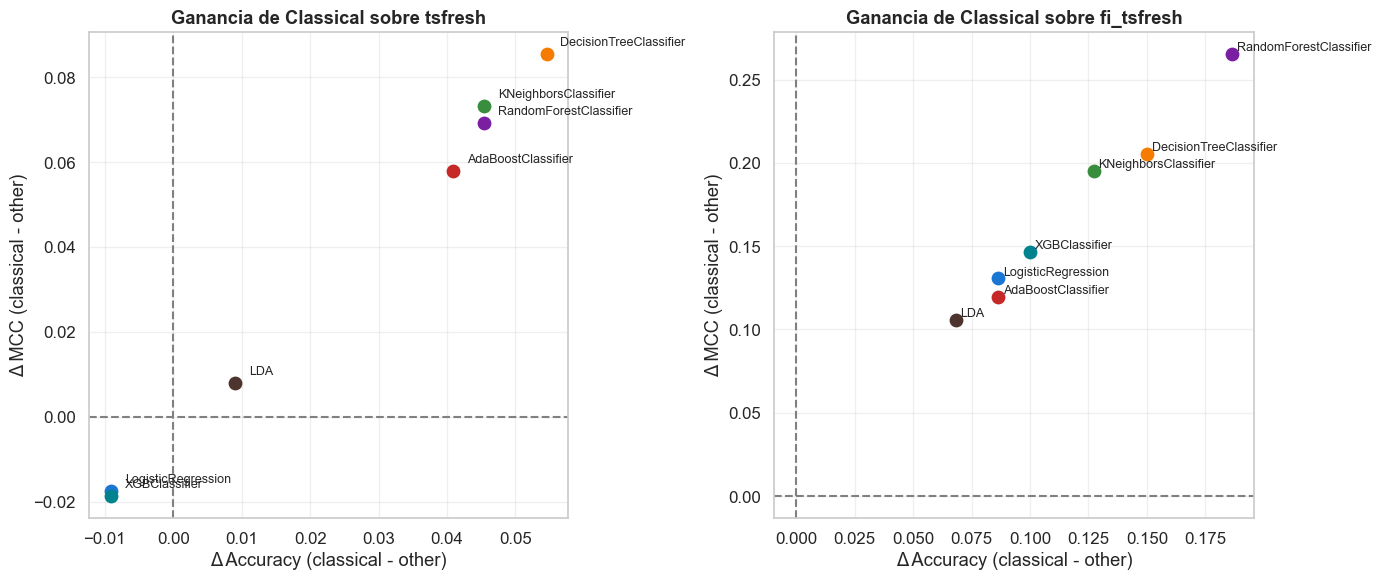

Classical supera a tsfresh en 5 de 7 modelos (Accuracy)
Reducción media de Accuracy (tsfresh): 0.025 puntos
Posible causa: las features biomecánicas clásicas tienen mayor valor predictivo real para esta tarea.
Classical supera a fi_tsfresh en 7 de 7 modelos (Accuracy)
Reducción media de Accuracy (fi_tsfresh): 0.115 puntos
Posible causa: las features biomecánicas clásicas tienen mayor valor predictivo real para esta tarea.


In [4]:
"""
============================================================================
CLASSICAL VS TSFRESH/FI_TSFRESH — Análisis de la diferencia
Compara el desempeño de ambos tipos de features por modelo.
============================================================================
"""

def _comparar_delta(df_base, df_other, label):
    if df_base.empty or df_other.empty:
        print(f"⚠️ Summary {label} no disponible. Se omite la comparación.")
        return pd.DataFrame()
    df_delta_local = pd.merge(
        df_base[['Model', 'Accuracy', 'MCC', 'ROC_AUC']],
        df_other[['Model', 'Accuracy', 'MCC', 'ROC_AUC']],
        on='Model',
        suffixes=('_classical', f'_{label}')
)
    df_delta_local['delta_accuracy'] = df_delta_local['Accuracy_classical'] - df_delta_local[f'Accuracy_{label}']
    df_delta_local['delta_mcc'] = df_delta_local['MCC_classical'] - df_delta_local[f'MCC_{label}']
    df_delta_local['delta_auc'] = df_delta_local['ROC_AUC_classical'] - df_delta_local[f'ROC_AUC_{label}']
    df_delta_local['comparacion'] = f'classical_vs_{label}'
    return df_delta_local

comparisons = []
plot_data = []

for label, df_other in [('tsfresh', df_tsfresh), ('fi_tsfresh', df_fi_tsfresh)]:
    df_delta_tmp = _comparar_delta(df_classical, df_other, label)
    if df_delta_tmp.empty:
        continue
    comparisons.append(df_delta_tmp)
    plot_data.append((label, df_delta_tmp))

if plot_data:
    n_comp = len(plot_data)
    fig, axes = plt.subplots(1, n_comp, figsize=(7 * n_comp, 6))
    if n_comp == 1:
        axes = [axes]
    for ax, (label, df_delta_tmp) in zip(axes, plot_data):
        for _, row in df_delta_tmp.iterrows():
            color = Config.MODEL_COLORS.get(row['Model'], '#616161')
            ax.scatter(row['delta_accuracy'], row['delta_mcc'], s=80, color=color)
            ax.text(row['delta_accuracy'] + 0.002, row['delta_mcc'] + 0.002, row['Model'], fontsize=9)
        ax.axvline(0, color='gray', linestyle='--')
        ax.axhline(0, color='gray', linestyle='--')
        ax.set_title(f'Ganancia de Classical sobre {label}', fontweight='bold')
        ax.set_xlabel('Δ Accuracy (classical - other)')
        ax.set_ylabel('Δ MCC (classical - other)')
        ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(f"{Config.RUTA_SALIDA}/figuras/classical_vs_tsfresh.png", dpi=150, bbox_inches='tight')
    plt.show()

    for label, df_delta_tmp in plot_data:
        n_better = int((df_delta_tmp['delta_accuracy'] > 0).sum())
        mean_delta = df_delta_tmp['delta_accuracy'].mean()
        print(f"Classical supera a {label} en {n_better} de {len(df_delta_tmp)} modelos (Accuracy)")
        print(f"Reducción media de Accuracy ({label}): {mean_delta:.3f} puntos")
        print("Posible causa: las features biomecánicas clásicas tienen mayor valor predictivo real para esta tarea.")
else:
    print('⚠️ No hay comparaciones disponibles.')
    df_delta = pd.DataFrame()

df_delta = pd.concat(comparisons, ignore_index=True) if comparisons else pd.DataFrame()

---
## CELDA 5 — Confusion matrices normalizadas

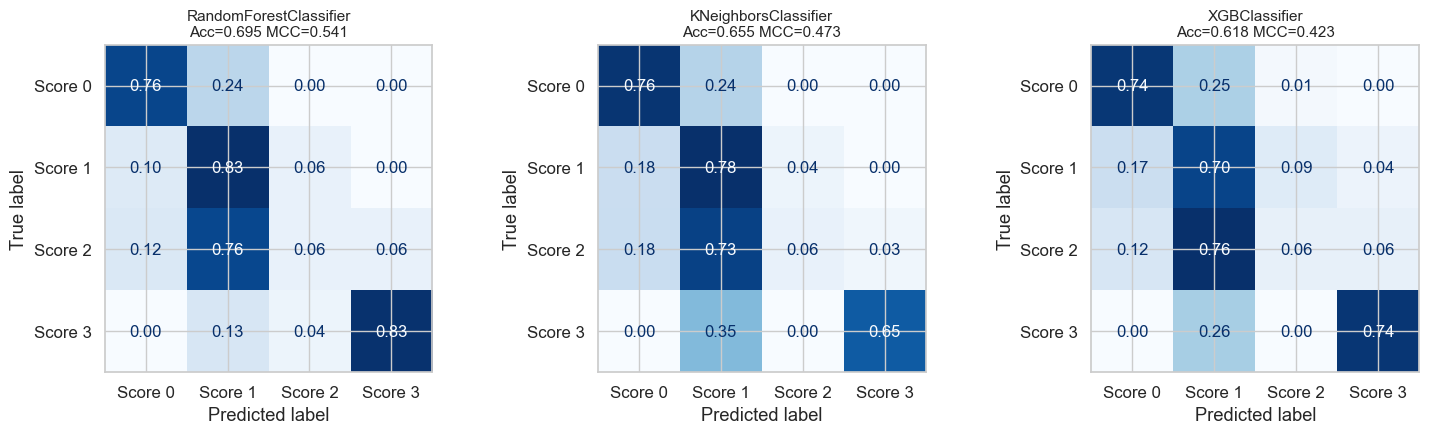

💾 Matrices de confusión guardadas (classical)
[classical] Score 2 recall — LogisticRegression: 0.061
[classical] Score 2 recall — KNeighborsClassifier: 0.061
[classical] Score 2 recall — DecisionTreeClassifier: 0.333
[classical] Score 2 recall — RandomForestClassifier: 0.061
[classical] Score 2 recall — AdaBoostClassifier: 0.152
[classical] Score 2 recall — XGBClassifier: 0.061
[classical] Score 2 recall — LDA: 0.152
[classical] Score 2 tiene el recall más bajo en 7 modelos, consistente con el IMU donde AUC Score 2 = 0.781


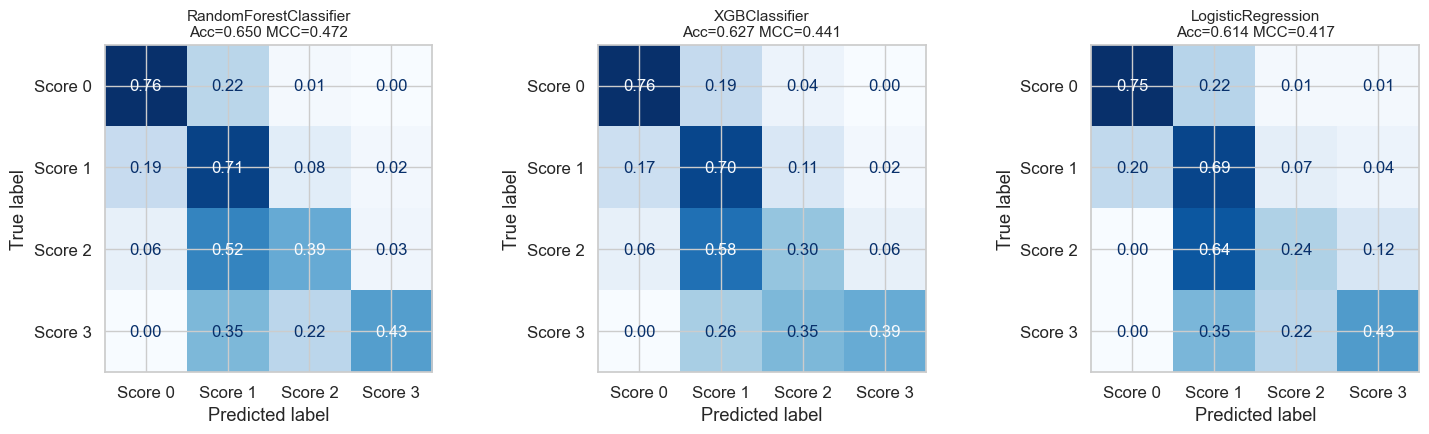

💾 Matrices de confusión guardadas (tsfresh)
[tsfresh] Score 2 recall — LogisticRegression: 0.242
[tsfresh] Score 2 recall — KNeighborsClassifier: 0.333
[tsfresh] Score 2 recall — DecisionTreeClassifier: 0.303
[tsfresh] Score 2 recall — RandomForestClassifier: 0.394
[tsfresh] Score 2 recall — AdaBoostClassifier: 0.182
[tsfresh] Score 2 recall — XGBClassifier: 0.303
[tsfresh] Score 2 recall — LDA: 0.303
[tsfresh] Score 2 tiene el recall más bajo en 6 modelos, consistente con el IMU donde AUC Score 2 = 0.781


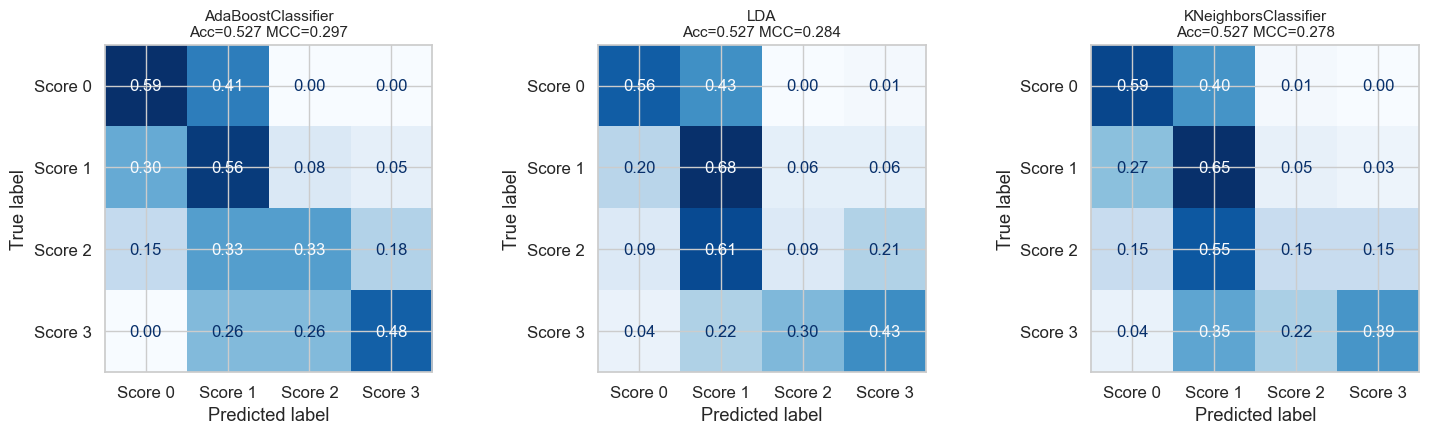

💾 Matrices de confusión guardadas (fi_tsfresh)
[fi_tsfresh] Score 2 recall — LogisticRegression: 0.091
[fi_tsfresh] Score 2 recall — KNeighborsClassifier: 0.152
[fi_tsfresh] Score 2 recall — DecisionTreeClassifier: 0.273
[fi_tsfresh] Score 2 recall — RandomForestClassifier: 0.121
[fi_tsfresh] Score 2 recall — AdaBoostClassifier: 0.333
[fi_tsfresh] Score 2 recall — XGBClassifier: 0.273
[fi_tsfresh] Score 2 recall — LDA: 0.091
[fi_tsfresh] Score 2 tiene el recall más bajo en 7 modelos, consistente con el IMU donde AUC Score 2 = 0.781


In [5]:
"""
============================================================================
MATRICES DE CONFUSIÓN NORMALIZADAS — Análisis por clase
Usa normalize='true' para reportar recall por clase.
============================================================================
"""

summaries_map = {
    'classical': df_classical,
    'tsfresh': df_tsfresh,
    'fi_tsfresh': df_fi_tsfresh
}

for ft in Config.FEATURES_TYPES:
    raw_path = Config.RAW_PATHS.get(ft)
    if not raw_path or not os.path.exists(raw_path):
        print(f"⚠️ Pickle no encontrado ({ft}): {raw_path}")
        continue
    with open(raw_path, 'rb') as f:
        data_raw = pickle.load(f)
    if not data_raw:
        print(f"⚠️ Pickle vacío ({ft}).")
        continue
    sub_summary = summaries_map.get(ft, pd.DataFrame())
    if not sub_summary.empty:
        top3_models = sub_summary.sort_values('MCC', ascending=False)['Model'].head(3).tolist()
    else:
        top3_models = list(data_raw.keys())[:3]

    if not top3_models:
        print(f"⚠️ Sin modelos para {ft}.")
        continue

    fig, axes = plt.subplots(1, len(top3_models), figsize=(5 * len(top3_models), 4.5))
    if len(top3_models) == 1:
        axes = [axes]

    for ax, model in zip(axes, top3_models):
        y_true = np.array(data_raw[model]['y_true'])
        y_pred = np.array(data_raw[model]['y_pred'])
        labels = sorted(np.unique(y_true))
        cm = confusion_matrix(y_true, y_pred, labels=labels, normalize='true')
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f'Score {s}' for s in labels])
        disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='.2f')
        acc = accuracy_score(y_true, y_pred)
        if not sub_summary.empty and (sub_summary['Model'] == model).any():
            mcc = float(sub_summary.loc[sub_summary['Model'] == model, 'MCC'].values[0])
        else:
            mcc = np.nan
        ax.set_title(f"{model}\nAcc={acc:.3f} MCC={mcc:.3f}", fontsize=11)
        for text in disp.text_.ravel():
            text.set_fontsize(12)

    plt.tight_layout()
    fig.savefig(f"{Config.RUTA_SALIDA}/figuras/confusion_matrices_top3_{ft}.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 Matrices de confusión guardadas ({ft})")

    count_lowest = 0
    count_total = 0
    for model, vals in data_raw.items():
        y_true = np.array(vals['y_true'])
        y_pred = np.array(vals['y_pred'])
        labels = sorted(np.unique(y_true))
        if 2 not in labels:
            continue
        cm = confusion_matrix(y_true, y_pred, labels=labels, normalize='true')
        recalls = np.diag(cm)
        recall_score2 = float(recalls[labels.index(2)])
        count_total += 1
        if recall_score2 == recalls.min():
            count_lowest += 1
        print(f"[{ft}] Score 2 recall — {model}: {recall_score2:.3f}")
    if count_total > 0:
        print(f"[{ft}] Score 2 tiene el recall más bajo en {count_lowest} modelos, consistente con el IMU donde AUC Score 2 = 0.781")

---
## CELDA 6 — ROC curves comparativas

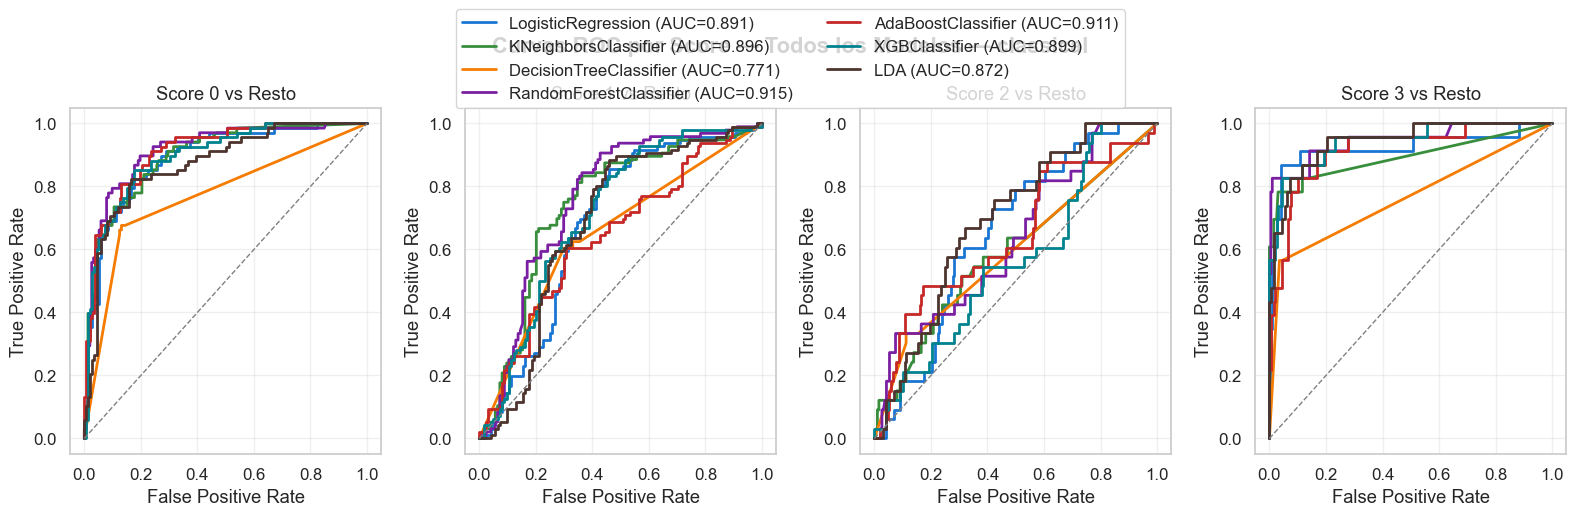

score                       0      1      2      3
model                                             
AdaBoostClassifier      0.911  0.643  0.645  0.916
DecisionTreeClassifier  0.771  0.649  0.595  0.763
KNeighborsClassifier    0.896  0.745  0.593  0.892
LDA                     0.872  0.688  0.697  0.944
LogisticRegression      0.891  0.685  0.658  0.922
RandomForestClassifier  0.915  0.760  0.635  0.946
XGBClassifier           0.899  0.716  0.567  0.944
★ Mayor AUC promedio ponderado (classical): RandomForestClassifier = 0.809


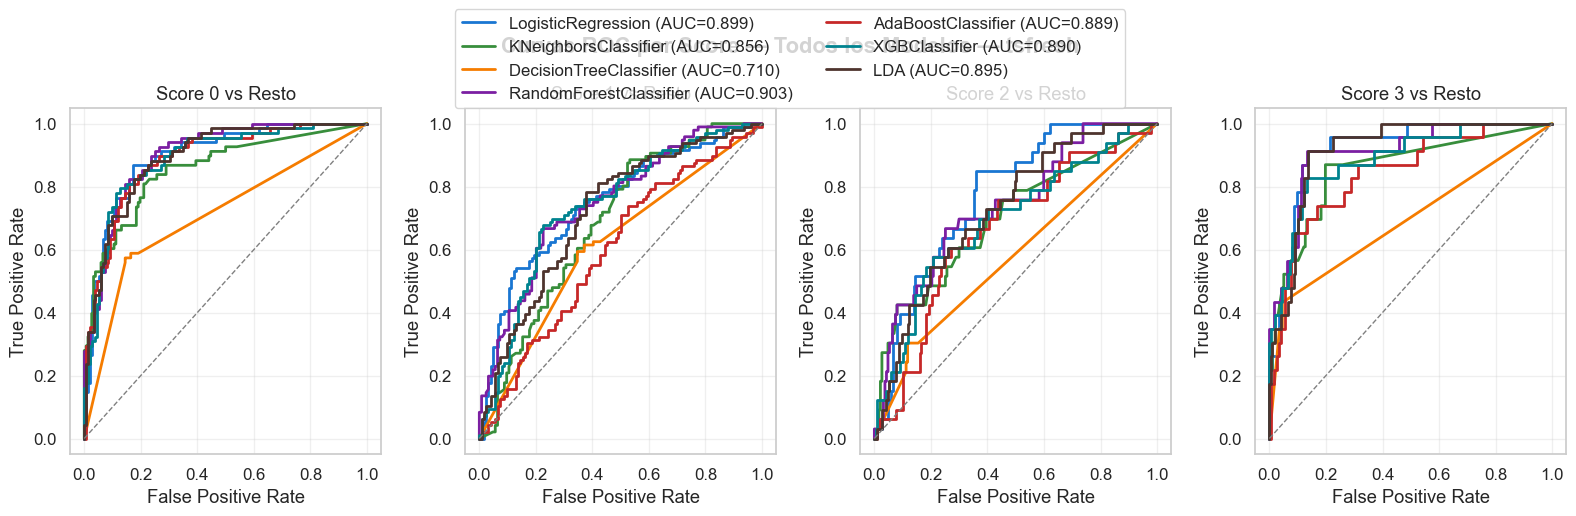

score                       0      1      2      3
model                                             
AdaBoostClassifier      0.889  0.602  0.665  0.842
DecisionTreeClassifier  0.710  0.612  0.575  0.693
KNeighborsClassifier    0.856  0.685  0.699  0.857
LDA                     0.895  0.721  0.730  0.916
LogisticRegression      0.899  0.751  0.775  0.921
RandomForestClassifier  0.903  0.748  0.738  0.909
XGBClassifier           0.890  0.741  0.696  0.885
★ Mayor AUC promedio ponderado (tsfresh): LogisticRegression = 0.818


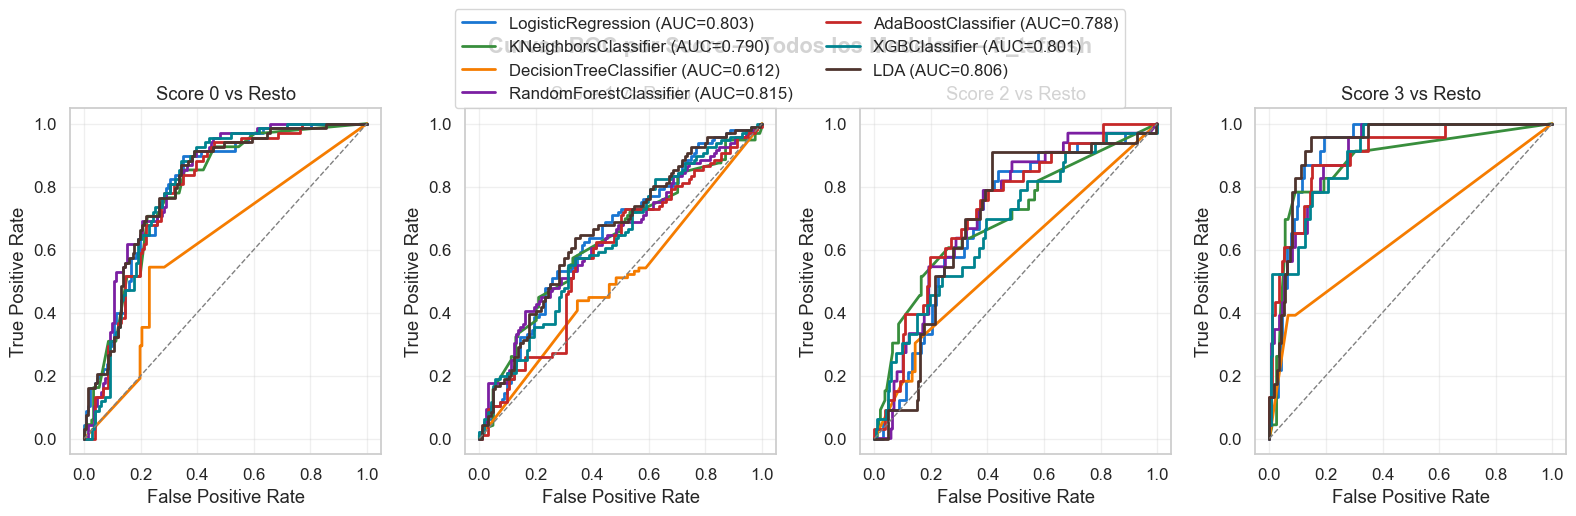

score                       0      1      2      3
model                                             
AdaBoostClassifier      0.788  0.589  0.730  0.901
DecisionTreeClassifier  0.612  0.504  0.575  0.655
KNeighborsClassifier    0.790  0.628  0.699  0.878
LDA                     0.806  0.657  0.700  0.929
LogisticRegression      0.803  0.645  0.698  0.923
RandomForestClassifier  0.815  0.634  0.720  0.908
XGBClassifier           0.801  0.624  0.678  0.902
★ Mayor AUC promedio ponderado (fi_tsfresh): LDA = 0.738


In [6]:
"""
============================================================================
CURVAS ROC COMPARATIVAS — Todos los modelos en una figura
Genera ROC OvR por score y reporta AUC por modelo.
============================================================================
"""

df_auc_all = {}
best_auc_by_type = {}

for ft in Config.FEATURES_TYPES:
    raw_path = Config.RAW_PATHS.get(ft)
    if not raw_path or not os.path.exists(raw_path):
        print(f"⚠️ Pickle no encontrado ({ft}): {raw_path}")
        continue
    with open(raw_path, 'rb') as f:
        data_raw = pickle.load(f)
    if not data_raw:
        print(f"⚠️ Pickle vacío ({ft}). No hay datos para ROC.")
        continue
    first_model = list(data_raw.keys())[0]
    ref_classes = sorted(np.unique(np.array(data_raw[first_model]['y_true'])))
    n_scores = len(ref_classes)

    fig, axes = plt.subplots(1, n_scores, figsize=(4 * n_scores, 5))
    if n_scores == 1:
        axes = [axes]

    auc_rows = []
    model_auc_weighted = []

    for model, vals in data_raw.items():
        y_true = np.array(vals['y_true'])
        y_proba = np.array(vals['y_proba'])
        if y_proba.ndim != 2 or y_proba.shape[1] != len(ref_classes):
            print(f"⚠️ Dimensión de probabilidades inesperada en {model} ({ft}). Se omite ROC.")
            continue
        y_bin = label_binarize(y_true, classes=ref_classes)

        for i, score in enumerate(ref_classes):
            ax = axes[i]
            fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
            auc_s = roc_auc_score(y_bin[:, i], y_proba[:, i])
            auc_rows.append({'model': model, 'score': score, 'auc': auc_s, 'feature_type': ft})
            color = Config.MODEL_COLORS.get(model, '#616161')
            ax.plot(fpr, tpr, color=color, lw=2, label=f"{model} (AUC={auc_s:.3f})")

        try:
            auc_w = roc_auc_score(y_bin, y_proba, multi_class='ovr', average='weighted')
            model_auc_weighted.append({'model': model, 'auc_weighted': auc_w})
        except Exception:
            pass

    for i, score in enumerate(ref_classes):
        axes[i].plot([0, 1], [0, 1], '--', color='gray', lw=1)
        axes[i].set_title(f"Score {score} vs Resto")
        axes[i].set_xlabel('False Positive Rate')
        axes[i].set_ylabel('True Positive Rate')
        axes[i].grid(alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.05))
    fig.suptitle(f"Curvas ROC por Score — Todos los Modelos — {ft}", fontweight='bold')
    plt.tight_layout()
    fig.savefig(f"{Config.RUTA_SALIDA}/figuras/roc_comparativas_{ft}.png", dpi=150, bbox_inches='tight')
    plt.show()

    df_auc = pd.DataFrame(auc_rows)
    df_auc_all[ft] = df_auc
    if not df_auc.empty:
        print(df_auc.pivot_table(index='model', columns='score', values='auc').round(3).to_string())

    if model_auc_weighted:
        df_auc_w = pd.DataFrame(model_auc_weighted)
        best_model_auc = df_auc_w.sort_values('auc_weighted', ascending=False).iloc[0]
        best_auc_by_type[ft] = best_model_auc
        print(f"★ Mayor AUC promedio ponderado ({ft}): {best_model_auc['model']} = {best_model_auc['auc_weighted']:.3f}")

---
## CELDA 7 — Análisis de sobreajuste

feature_type                  model  train_acc  test_acc   gap  n_folds  n_features_mean                        interpretacion
   classical DecisionTreeClassifier      0.962     0.577 0.385      220           31.000 Sobreajuste severo — revisar pipeline
   classical          XGBClassifier      1.000     0.618 0.382      220           31.000 Sobreajuste severo — revisar pipeline
   classical   KNeighborsClassifier      0.966     0.655 0.312      220           31.000 Sobreajuste severo — revisar pipeline
   classical RandomForestClassifier      0.997     0.695 0.301      220           31.000 Sobreajuste severo — revisar pipeline
   classical     AdaBoostClassifier      0.721     0.614 0.107      220           31.000          Sobreajuste leve — aceptable
   classical     LogisticRegression      0.709     0.605 0.105      220           31.000          Sobreajuste leve — aceptable
   classical                    LDA      0.682     0.595 0.086      220           31.000         Sin sobreajust

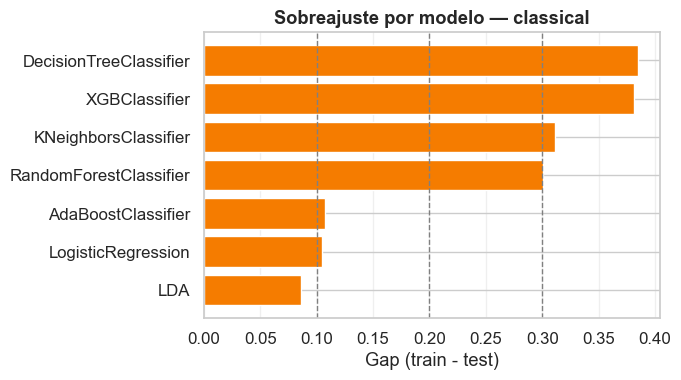

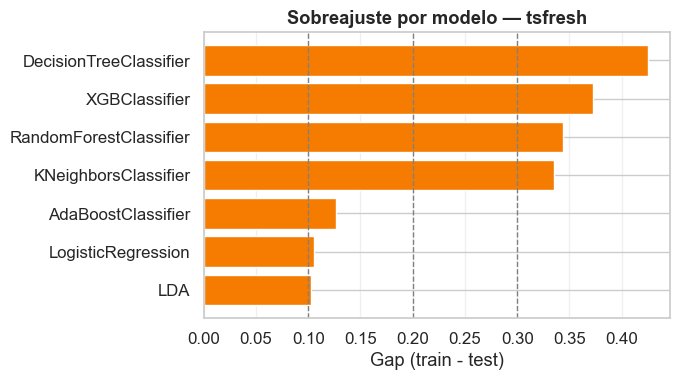

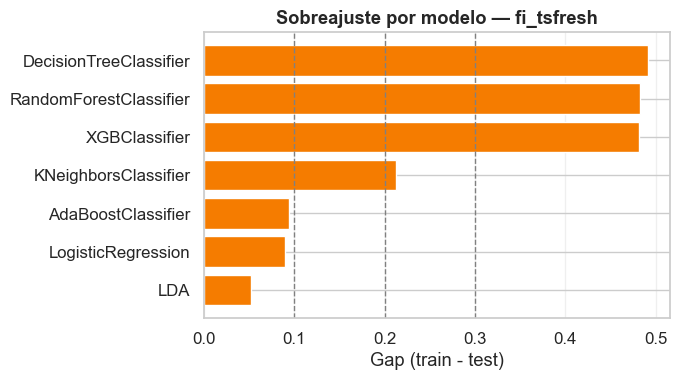

In [7]:
"""
============================================================================
ANALISIS DE SOBREAJUSTE — Gap train vs test (LOO)
Calcula el gap usando los logs por fold generados en el entrenamiento.
Si falta el log, intenta reconstruirlo desde modelos guardados.
============================================================================
"""

def interpretar_gap(gap):
    if gap < 0.10:
        return 'Sin sobreajuste significativo'
    if gap < 0.20:
        return 'Sobreajuste leve — aceptable'
    if gap < 0.30:
        return 'Sobreajuste moderado — reportar'
    return 'Sobreajuste severo — revisar pipeline'


def _listar_modelos_guardados(features_type):
    model_dir = f"{Config.RUTA_RESULTS}models/"
    if not os.path.exists(model_dir):
        return []
    prefix = f"{Config.DATASET_ID}_{features_type}_"
    model_names = set()
    for fname in os.listdir(model_dir):
        if not fname.startswith(prefix) or "_fold_" not in fname or not fname.endswith(".joblib"):
            continue
        model_name = fname[len(prefix):].split("_fold_")[0]
        model_names.add(model_name)
    return sorted(model_names)


def _reconstruir_overfit_classical():
    features_path = Config.FEATURES_PATHS.get("classical")
    diag_path = Config.DIAG_PATH
    model_dir = f"{Config.RUTA_RESULTS}models/"

    if not features_path or not os.path.exists(features_path):
        print(f"⚠️ Features classical no encontradas: {features_path}")
        return pd.DataFrame()
    if not os.path.exists(diag_path):
        print(f"⚠️ Diagnosticos no encontrados: {diag_path}")
        return pd.DataFrame()
    if not os.path.exists(model_dir):
        print(f"⚠️ Carpeta de modelos no encontrada: {model_dir}")
        return pd.DataFrame()

    model_names = _listar_modelos_guardados("classical")
    if not model_names:
        print("⚠️ No hay modelos guardados para classical.")
        return pd.DataFrame()

    features = pd.read_csv(features_path, dtype={"Unnamed: 0": str})
    features = features.rename(columns={"Unnamed: 0": "ID"})
    features = features.sort_values(by=["ID"])

    y_diagnostic = pd.read_csv(diag_path, dtype={"UPDRS": np.int32, "ID": str})
    y_diagnostic = y_diagnostic.sort_values(by=["ID"]).drop_duplicates().reset_index(drop=True)

    merged = (
        y_diagnostic
        .merge(features, on="ID", how="inner")
        .sort_values(by="ID")
        .reset_index(drop=True)
    )
    if merged.empty:
        print("⚠️ No hay interseccion entre diagnosticos y features.")
        return pd.DataFrame()

    y = merged["UPDRS"].to_numpy()
    X = merged.drop(columns=["ID", "UPDRS"]).to_numpy()

    loo = LeaveOneOut()
    rows = []
    errors = []

    import joblib

    for fold_idx, (train_idx, test_idx) in enumerate(loo.split(X)):
        X_train = X[train_idx]
        X_test = X[test_idx]
        y_train = y[train_idx]
        y_test = y[test_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        for model_name in model_names:
            model_path = (
                f"{model_dir}"
                f"{Config.DATASET_ID}_classical_{model_name}_fold_{fold_idx}.joblib"
            )
            if not os.path.exists(model_path):
                continue
            try:
                model = joblib.load(model_path)
                train_pred = model.predict(X_train)
                test_pred = model.predict(X_test)
            except Exception as exc:
                errors.append(f"{model_name} fold {fold_idx}: {exc}")
                continue

            rows.append(
                {
                    "feature_type": "classical",
                    "fold": fold_idx,
                    "model": model_name,
                    "train_acc": accuracy_score(y_train, train_pred),
                    "test_acc": accuracy_score(y_test, test_pred),
                    "n_features": X_train.shape[1],
                }
            )

    df = pd.DataFrame(rows)
    if df.empty:
        print("⚠️ Reconstruccion fallida: sin filas.")
    elif errors:
        print(f"⚠️ Reconstruccion con {len(errors)} fallos (ejemplo: {errors[0]})")
    return df


def _cargar_overfit_logs(features_type):
    path = (
        f"{Config.RUTA_RESULTS}overfit/"
        f"{Config.DATASET_ID}_{features_type}_train_test_accuracy_by_fold.csv"
    )
    if os.path.exists(path):
        df = pd.read_csv(path)
        if 'feature_type' not in df.columns:
            df['feature_type'] = features_type
        return df

    print(f"⚠️ Log de sobreajuste no encontrado: {path}")
    if features_type == "classical":
        df_fallback = _reconstruir_overfit_classical()
        if not df_fallback.empty:
            os.makedirs(os.path.dirname(path), exist_ok=True)
            df_fallback.to_csv(path, index=False)
            print(f"✅ Log de sobreajuste reconstruido: {path}")
        return df_fallback
    return pd.DataFrame()


dfs = []
for ft in Config.FEATURES_TYPES:
    df_ft = _cargar_overfit_logs(ft)
    if not df_ft.empty:
        dfs.append(df_ft)

df_overfit_raw = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

if df_overfit_raw.empty:
    print("⚠️ No hay logs de sobreajuste. Ejecuta el entrenamiento para generarlos.")
    df_overfit = pd.DataFrame()
else:
    df_overfit_raw['gap'] = df_overfit_raw['train_acc'] - df_overfit_raw['test_acc']
    df_overfit = (
        df_overfit_raw
        .groupby(['feature_type', 'model'])
        .agg(
            train_acc=('train_acc', 'mean'),
            test_acc=('test_acc', 'mean'),
            gap=('gap', 'mean'),
            n_folds=('fold', 'nunique'),
            n_features_mean=('n_features', 'mean')
        )
        .reset_index()
    )
    df_overfit['interpretacion'] = df_overfit['gap'].apply(interpretar_gap)

    print(
        df_overfit
        .sort_values(['feature_type', 'gap'], ascending=[True, False])
        .round(3)
        .to_string(index=False)
    )

    for ft in Config.FEATURES_TYPES:
        sub = df_overfit[df_overfit['feature_type'] == ft].sort_values('gap', ascending=False)
        if sub.empty:
            continue
        fig, ax = plt.subplots(figsize=(7, max(4, 0.35 * len(sub))))
        ax.barh(sub['model'], sub['gap'], color='#F57C00')
        ax.axvline(0.10, linestyle='--', color='gray', linewidth=1)
        ax.axvline(0.20, linestyle='--', color='gray', linewidth=1)
        ax.axvline(0.30, linestyle='--', color='gray', linewidth=1)
        ax.set_xlabel('Gap (train - test)')
        ax.set_title(f'Sobreajuste por modelo — {ft}', fontweight='bold')
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        fig.savefig(
            f"{Config.RUTA_SALIDA}/figuras/sobreajuste_gap_{ft}.png",
            dpi=150,
            bbox_inches='tight'
        )
        plt.show()

---
## CELDA 8 — Features seleccionadas por modelo (tsfresh / fi_tsfresh)

📌 tsfresh: 43 features distintas, 220 folds.
    Estables (>=80% folds): ACCELERATION__agg_autocorrelation__f_agg_"var"__maxlag_40, ACCELERATION__fourier_entropy__bins_10, ACCELERATION__fourier_entropy__bins_100, ACCELERATION__number_crossing_m__m_1, ACCELERATION__fourier_entropy__bins_3, ACCELERATION__fourier_entropy__bins_5, ACCELERATION__number_crossing_m__m_-1, ACCELERATION__number_crossing_m__m_0, SMOOTHED_AMPLITUDE__autocorrelation__lag_6, DISTANCE_ANG__autocorrelation__lag_6, ACCELERATION__ratio_beyond_r_sigma__r_3, VELOCITY__permutation_entropy__dimension_5__tau_1, VELOCITY__partial_autocorrelation__lag_5, VELOCITY__number_peaks__n_1, SMOOTHED_AMPLITUDE__ar_coefficient__coeff_0__k_10, DISTANCE_ANG__longest_strike_below_mean, VELOCITY__permutation_entropy__dimension_6__tau_1, VELOCITY__permutation_entropy__dimension_3__tau_1, SMOOTHED_AMPLITUDE__longest_strike_below_mean, VELOCITY__permutation_entropy__dimension_4__tau_1
    ... +4 más


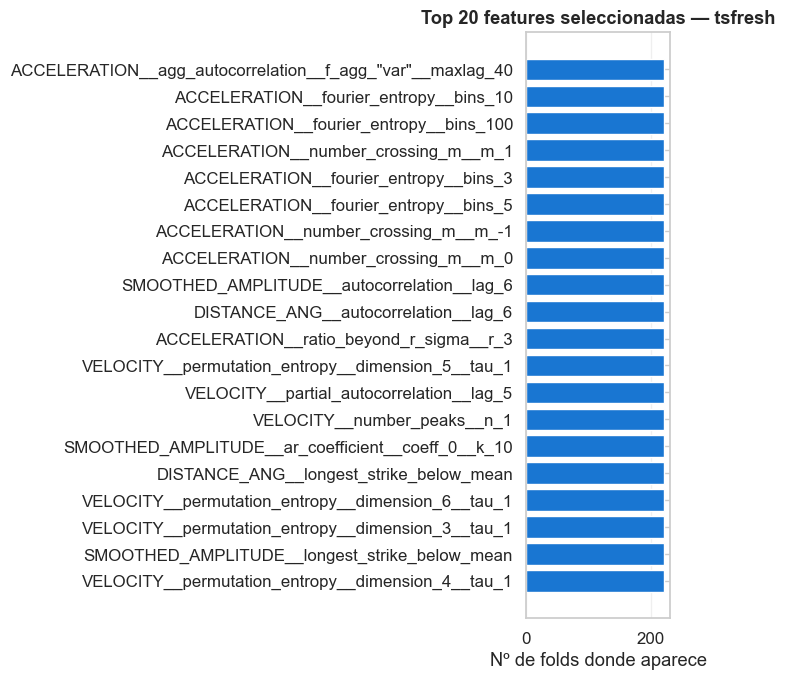

📌 fi_tsfresh: 17 features distintas, 220 folds.
    Estables (>=80% folds): IF_value__agg_linear_trend__attr_"stderr"__chunk_len_5__f_agg_"mean", IF_value__fft_coefficient__attr_"abs"__coeff_2, IF_value__agg_linear_trend__attr_"stderr"__chunk_len_5__f_agg_"min", IF_value__agg_linear_trend__attr_"stderr"__chunk_len_5__f_agg_"var", IF_value__fft_coefficient__attr_"abs"__coeff_3, IF_value__fft_coefficient__attr_"imag"__coeff_3, max_freq__skewness, IF_value__fft_coefficient__attr_"imag"__coeff_2, IF_value__cwt_coefficients__coeff_13__w_2__widths_(2, 5, 10, 20), IF_value__approximate_entropy__m_2__r_0.9


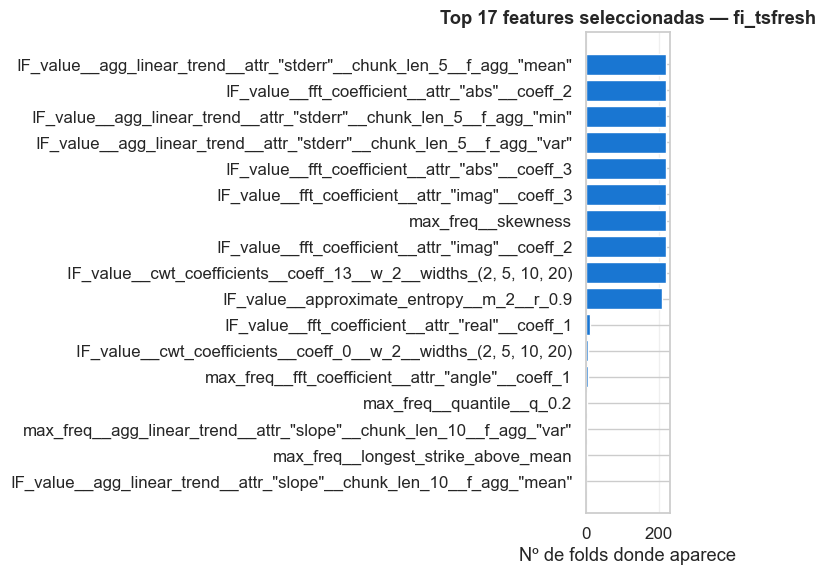

💾 Frecuencias de selección guardadas: ../results_files/analisis_modelos//tablas/features_seleccionadas_frecuencia.csv
ℹ️ Selección previa al modelo: la tabla por modelo replica el top-N de selección.
💾 Tabla por modelo guardada: ../results_files/analisis_modelos//tablas/features_seleccionadas_por_modelo.csv


In [8]:
"""
============================================================================
FEATURES SELECCIONADAS — TSFRESH / FI_TSFRESH
Resumen por fold y tabla por modelo (selección independiente del modelo).
============================================================================
"""

target_types = [ft for ft in Config.FEATURES_TYPES if ft in ["tsfresh", "fi_tsfresh"]]
freq_rows_all = []
model_rows_all = []

def _modelos_disponibles(ft):
    if 'df_all' in globals() and isinstance(df_all, pd.DataFrame) and not df_all.empty:
        sub = df_all[df_all['features_type'] == ft]
        if not sub.empty and 'Model' in sub.columns:
            return sorted(sub['Model'].dropna().unique().tolist())
    if 'df_overfit_raw' in globals() and isinstance(df_overfit_raw, pd.DataFrame) and not df_overfit_raw.empty:
        sub = df_overfit_raw[df_overfit_raw['feature_type'] == ft]
        if not sub.empty and 'model' in sub.columns:
            return sorted(sub['model'].dropna().unique().tolist())
    return []

for ft in target_types:
    sel_path = (
        f"{Config.RUTA_RESULTS}feature_selection/"
        f"{Config.DATASET_ID}_{ft}_selected_features_by_fold.csv"
    )
    if not os.path.exists(sel_path):
        print(f"⚠️ Log de selección no encontrado ({ft}): {sel_path}")
        continue

    df_sel = pd.read_csv(sel_path)
    if df_sel.empty:
        print(f"⚠️ Log vacío ({ft}).")
        continue

    if "feature_type" not in df_sel.columns:
        df_sel["feature_type"] = ft

    n_folds = int(df_sel["fold"].nunique())
    freq = (
        df_sel.groupby("feature")["fold"]
        .nunique()
        .reset_index(name="n_folds")
        .sort_values("n_folds", ascending=False)
    )
    freq["pct_folds"] = freq["n_folds"] / n_folds if n_folds else 0.0
    freq["feature_type"] = ft
    freq_rows_all.append(freq)

    top_k = min(20, len(freq))
    top = freq.head(top_k)

    print(f"📌 {ft}: {len(freq)} features distintas, {n_folds} folds.")
    stable = freq[freq["pct_folds"] >= 0.80]["feature"].tolist()
    if stable:
        print(f"    Estables (>=80% folds): {', '.join(stable[:20])}")
        if len(stable) > 20:
            print(f"    ... +{len(stable) - 20} más")
    else:
        print("    Estables (>=80% folds): ninguna")

    fig, ax = plt.subplots(figsize=(7, max(4, 0.35 * top_k)))
    ax.barh(top["feature"], top["n_folds"], color="#1976D2")
    ax.set_xlabel("Nº de folds donde aparece")
    ax.set_title(f"Top {top_k} features seleccionadas — {ft}", fontweight="bold")
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    fig.savefig(
        f"{Config.RUTA_SALIDA}/figuras/features_seleccionadas_top_{ft}.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()

    modelos = _modelos_disponibles(ft)
    if modelos:
        top_model_k = min(10, len(freq))
        top_model = freq.head(top_model_k)[["feature", "n_folds", "pct_folds"]].copy()
        top_model["key"] = 1
        df_modelos = pd.DataFrame({"model": modelos})
        df_modelos["key"] = 1
        df_cross = df_modelos.merge(top_model, on="key").drop(columns="key")
        df_cross["feature_type"] = ft
        model_rows_all.append(df_cross)

df_freq_all = pd.concat(freq_rows_all, ignore_index=True) if freq_rows_all else pd.DataFrame()
df_features_por_modelo = (
    pd.concat(model_rows_all, ignore_index=True) if model_rows_all else pd.DataFrame()
)

if not df_freq_all.empty:
    freq_path = f"{Config.RUTA_SALIDA}/tablas/features_seleccionadas_frecuencia.csv"
    df_freq_all.to_csv(freq_path, index=False)
    print(f"💾 Frecuencias de selección guardadas: {freq_path}")

if not df_features_por_modelo.empty:
    model_path = f"{Config.RUTA_SALIDA}/tablas/features_seleccionadas_por_modelo.csv"
    df_features_por_modelo.to_csv(model_path, index=False)
    print("ℹ️ Selección previa al modelo: la tabla por modelo replica el top-N de selección.")
    print(f"💾 Tabla por modelo guardada: {model_path}")

---
## CELDA 9 — Análisis Score 2

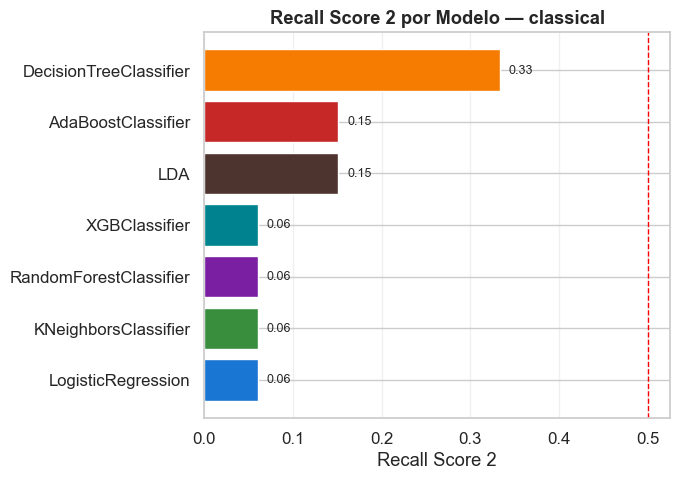

Score 2 (síntomas moderados) es la clase más difícil en classical.
Recall promedio (classical): 0.13. Esto es consistente con el IMU (AUC Score 2 = 0.781).


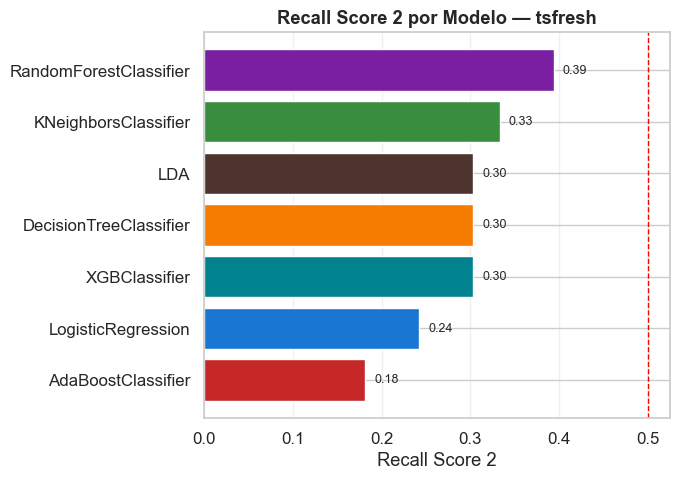

Score 2 (síntomas moderados) es la clase más difícil en tsfresh.
Recall promedio (tsfresh): 0.29. Esto es consistente con el IMU (AUC Score 2 = 0.781).


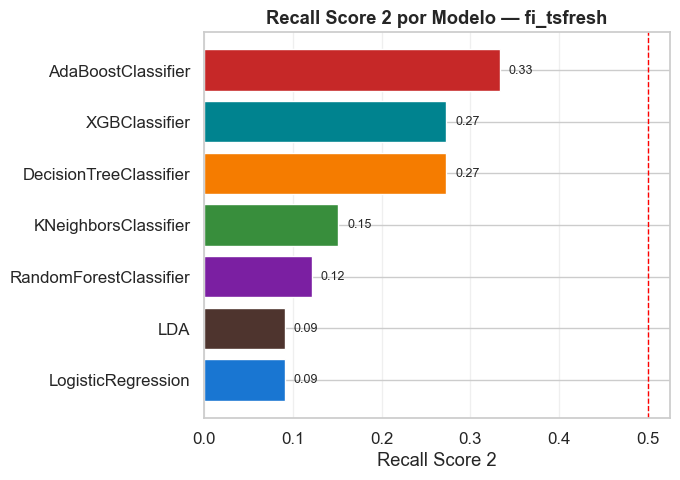

Score 2 (síntomas moderados) es la clase más difícil en fi_tsfresh.
Recall promedio (fi_tsfresh): 0.19. Esto es consistente con el IMU (AUC Score 2 = 0.781).


In [9]:
"""
============================================================================
ANÁLISIS ESPECIAL — Score 2 como clase más difícil
Evalúa el recall de Score 2 por modelo y su promedio.
============================================================================
"""

recall_rows = []
mean_recall2_by_type = {}

for ft in Config.FEATURES_TYPES:
    raw_path = Config.RAW_PATHS.get(ft)
    if not raw_path or not os.path.exists(raw_path):
        print(f"⚠️ Pickle no encontrado ({ft}): {raw_path}")
        continue
    with open(raw_path, 'rb') as f:
        data_raw = pickle.load(f)
    if not data_raw:
        print(f"⚠️ Pickle vacío ({ft}).")
        continue

    ft_rows = []
    for model, vals in data_raw.items():
        y_true = np.array(vals['y_true'])
        y_pred = np.array(vals['y_pred'])
        labels = sorted(np.unique(y_true))
        cm = confusion_matrix(y_true, y_pred, labels=labels, normalize='true')
        for i, s in enumerate(labels):
            row = {'feature_type': ft, 'model': model, 'score': s, 'recall': cm[i, i]}
            recall_rows.append(row)
            ft_rows.append(row)

    df_ft = pd.DataFrame(ft_rows)
    df_score2_ft = df_ft[df_ft['score'] == 2].sort_values('recall')
    if df_score2_ft.empty:
        print(f"⚠️ Sin Score 2 en {ft}.")
        continue

    fig, ax = plt.subplots(figsize=(7, 5))
    colors = [Config.MODEL_COLORS.get(m, '#616161') for m in df_score2_ft['model']]
    ax.barh(df_score2_ft['model'], df_score2_ft['recall'], color=colors)
    ax.axvline(0.5, linestyle='--', color='red', linewidth=1)
    ax.set_xlabel('Recall Score 2')
    ax.set_title(f'Recall Score 2 por Modelo — {ft}', fontweight='bold')
    for i, v in enumerate(df_score2_ft['recall']):
        ax.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    fig.savefig(f"{Config.RUTA_SALIDA}/figuras/recall_score2_{ft}.png", dpi=150, bbox_inches='tight')
    plt.show()

    mean_recall2 = df_score2_ft['recall'].mean()
    mean_recall2_by_type[ft] = mean_recall2
    print(f"Score 2 (síntomas moderados) es la clase más difícil en {ft}.")
    print(f"Recall promedio ({ft}): {mean_recall2:.2f}. Esto es consistente con el IMU (AUC Score 2 = 0.781).")

df_recall = pd.DataFrame(recall_rows)
df_score2 = df_recall[df_recall['score'] == 2] if not df_recall.empty else pd.DataFrame()

---
## CELDA 10 — Exportación final

In [10]:
"""
============================================================================
EXPORTACIÓN FINAL — Excel con todos los resultados
Consolida tablas y un resumen ejecutivo del análisis.
============================================================================
"""

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
excel_path = f"{Config.RUTA_SALIDA}/tablas/analisis_modelos_{timestamp}.xlsx"

df_classical_sorted = df_classical.sort_values('MCC', ascending=False) if not df_classical.empty else pd.DataFrame()
df_tsfresh_sorted = df_tsfresh.sort_values('MCC', ascending=False) if not df_tsfresh.empty else pd.DataFrame()
df_fi_sorted = df_fi_tsfresh.sort_values('MCC', ascending=False) if not df_fi_tsfresh.empty else pd.DataFrame()

if 'df_delta' not in globals():
    df_delta = pd.DataFrame()
if 'df_overfit' not in globals():
    df_overfit = pd.DataFrame()
if 'df_recall' not in globals():
    df_recall = pd.DataFrame()
if 'df_score2' not in globals():
    df_score2 = pd.DataFrame()
if 'df_freq_all' not in globals():
    df_freq_all = pd.DataFrame()
if 'interpretar_gap' not in globals():
    def interpretar_gap(gap):
        if gap < 0.10:
            return 'Sin sobreajuste significativo'
        if gap < 0.20:
            return 'Sobreajuste leve — aceptable'
        if gap < 0.30:
            return 'Sobreajuste moderado — reportar'
        return 'Sobreajuste severo — revisar pipeline'

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    df_classical_sorted.to_excel(writer, sheet_name='classical_summary', index=False)
    df_tsfresh_sorted.to_excel(writer, sheet_name='tsfresh_summary', index=False)
    df_fi_sorted.to_excel(writer, sheet_name='fi_tsfresh_summary', index=False)
    df_delta.to_excel(writer, sheet_name='comparacion_delta', index=False)
    df_overfit.to_excel(writer, sheet_name='sobreajuste', index=False)
    df_recall.to_excel(writer, sheet_name='recall_por_score', index=False)
    if not df_freq_all.empty:
        df_freq_all.to_excel(writer, sheet_name='features_estables', index=False)

print(f"💾 Excel exportado: {excel_path}")

best_global = df_classical_sorted.iloc[0] if not df_classical_sorted.empty else None
if best_global is not None:
    print(f"Mejor modelo global: {best_global['Model']} Classical, MCC={best_global['MCC']:.3f}, AUC={best_global['ROC_AUC']:.3f}")

mask_lda = df_classical_sorted['Model'].isin(['LDA', 'LinearDiscriminantAnalysis']) if not df_classical_sorted.empty else []
if isinstance(mask_lda, pd.Series) and mask_lda.any():
    row_lda = df_classical_sorted[mask_lda].iloc[0]
    print(f"LDA Classical: Acc={row_lda['Accuracy']:.3f}, AUC={row_lda['ROC_AUC']:.3f} (referencia IMU)")

if not df_delta.empty and 'comparacion' in df_delta.columns:
    for comp in df_delta['comparacion'].unique():
        sub = df_delta[df_delta['comparacion'] == comp]
        comp_label = comp.replace('classical_vs_', '')
        n_better = int((sub['delta_accuracy'] > 0).sum())
        print(f"Classical supera {comp_label} en {n_better} de {len(sub)} modelos")
elif not df_delta.empty:
    n_better = int((df_delta['delta_accuracy'] > 0).sum())
    print(f"Classical supera otros features en {n_better} de {len(df_delta)} modelos")
else:
    print('⚠️ Comparaciones Classical vs otros features no disponibles')

if not df_score2.empty:
    for ft in df_score2['feature_type'].unique():
        mean_recall2 = df_score2[df_score2['feature_type'] == ft]['recall'].mean()
        print(f"Score 2 es el más difícil en {ft} (recall promedio: {mean_recall2:.2f})")
else:
    print('⚠️ Sin datos de Score 2 para resumen')

if 'gap_rf' in globals() and not np.isnan(gap_rf):
    print(f"Gap sobreajuste RF (classical): {gap_rf:.3f} → {interpretar_gap(gap_rf)}")

💾 Excel exportado: ../results_files/analisis_modelos//tablas/analisis_modelos_20260510_192233.xlsx
Mejor modelo global: RandomForestClassifier Classical, MCC=0.541, AUC=0.809
LDA Classical: Acc=0.595, AUC=0.773 (referencia IMU)
Classical supera tsfresh en 5 de 7 modelos
Classical supera fi_tsfresh en 7 de 7 modelos
Score 2 es el más difícil en classical (recall promedio: 0.13)
Score 2 es el más difícil en tsfresh (recall promedio: 0.29)
Score 2 es el más difícil en fi_tsfresh (recall promedio: 0.19)
